In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Inżynieria cech

Budujemy zbiór treningowy z oczyszczonych danych (`data/interim/`).


- definiujemy etykietę `Y`, czyli rezerwację po obejrzeniu oferty w oknie 24h,
- liczymy cechy recenzji widoczne w momencie sesji,
- dołączamy cechy oferty i wybieramy strategię imputacji braków numerycznych empirycznie (porównanie w walidacji krzyżowej),
- sprawdzamy, czy te cechy różnią się dla `Y=0` i `Y=1`,
- trenujemy i zapisujemy **model bazowy A** (regresja logistyczna) jako gotowy pipeline.

## Konstrukcja Y (etykieta)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reviews_df = pd.read_csv("../data/interim/reviews_processed.csv")
sessions_df_clean = pd.read_csv("../data/interim/sessions_processed.csv")
listings_df = pd.read_csv("../data/interim/listings_processed.csv")

# Parsowanie dat
reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['date'])
sessions_df_clean['timestamp'] = pd.to_datetime(sessions_df_clean['timestamp'])

print(f"Recenzje: {reviews_df.shape}")
print(f"Sesje: {sessions_df_clean.shape}")
print(f"Listings: {listings_df.shape}")


Recenzje: (46935, 9)
Sesje: (470445, 4)
Listings: (3646, 12)


In [3]:
# Zostawiamy tylko istotne typy sesji
sessions_filtered = sessions_df_clean[sessions_df_clean['action'].isin(['view_listing', 'book_listing'])].copy()
sessions_filtered = sessions_filtered.drop_duplicates()

# Rozdzielamy obejrzenia od rezerwacji
views_df = sessions_filtered[sessions_filtered["action"] ==
                             "view_listing"][['user_id', 'timestamp', 'listing_id']].copy()
bookings_df = sessions_filtered[sessions_filtered["action"] ==
                                "book_listing"][['user_id', 'listing_id', 'timestamp']].copy()
bookings_df = bookings_df.rename(columns={'timestamp': 'booking_timestamp'})

# Złączenie point-in-time w przód: dla każdego obejrzenia sprawdzamy rezerwację w oknie 24h
views_df = views_df.sort_values('timestamp')
bookings_df = bookings_df.sort_values('booking_timestamp')
merged_df = pd.merge_asof(
    left=views_df,
    right=bookings_df,
    left_on='timestamp',
    right_on='booking_timestamp',
    by=['user_id', 'listing_id'],
    direction='forward',
    tolerance=pd.Timedelta(hours=24)
)

# Y=1, jeśli jest timestamp rezerwacji (oferta została zarezerwowana)
merged_df['Y'] = merged_df['booking_timestamp'].notna().astype(int)
training_data = merged_df.drop(columns=['booking_timestamp']).reset_index(drop=True)
print(f"Zbiór treningowy: {training_data.shape}")


Zbiór treningowy: (431281, 4)


In [4]:
print(len(training_data[training_data["Y"] == 1]))
print(len(training_data[training_data["Y"] == 0]))

15546
415735


## Konstrukcja cech (X)

Dla każdego `view_listing` liczymy cechy dostępne w momencie sesji. Recenzję z dnia `D` uznajemy za widoczną dopiero od `D+1`.

Cechy z recenzji:

| Cecha                     | Opis                                                        |
| ------------------------- | ----------------------------------------------------------- |
| `days_since_last_review`  | dni od ostatniej widocznej recenzji; `-1` gdy brak recenzji |
| `reviews_in_last_90_days` | liczba recenzji z ostatnich 90 dni                          |
| `recent_review_scores_*`  | średnie sentymenty z ostatnich 90 dni                       |
| `alltime_review_count`    | liczba wszystkich widocznych recenzji                       |
| `alltime_review_scores_*` | średnie sentymenty ze wszystkich widocznych recenzji        |

Na końcu dokładamy cechy z `Listings`.


In [5]:
sentiment_cols = [c for c in reviews_df.columns if c.startswith('review_scores_')]

# Recenzja widoczna dopiero od D+1
reviews_df['visible_date'] = reviews_df['date'] + pd.Timedelta(days=1)

# CECHA: days_since_last_review
# merge_asof backward: najnowsza recenzja widoczna przed sesją
td_sorted = training_data[['listing_id', 'timestamp']].copy()
td_sorted['_orig_idx'] = td_sorted.index
td_sorted = td_sorted.sort_values('timestamp')

rv_for_asof = reviews_df[['listing_id', 'visible_date', 'date']].sort_values('visible_date')

asof_result = pd.merge_asof(
    td_sorted,
    rv_for_asof.rename(columns={'visible_date': '_vis_ts', 'date': '_review_date'}),
    left_on='timestamp',
    right_on='_vis_ts',
    by='listing_id',
    direction='backward'
)
asof_result['days_since_last_review'] = (asof_result['timestamp'] - asof_result['_review_date']).dt.days

# NaN = oferta nie ma żadnej recenzji → wypełniamy -1
training_data['days_since_last_review'] = (
    asof_result.set_index('_orig_idx')['days_since_last_review'].fillna(-1).astype(int)
)

pct_no_review = (training_data['days_since_last_review'] == -1).mean() * 100
print(f"days_since_last_review: {pct_no_review:.1f}% bez recenzji (wypełnione -1)")
print(training_data['days_since_last_review'].describe())


days_since_last_review: 73.0% bez recenzji (wypełnione -1)
count    431281.000000
mean        158.668610
std         445.360041
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          21.000000
max        4271.000000
Name: days_since_last_review, dtype: float64


In [6]:
# CECHY: okno 90 dni + cechy historyczne (all-time)
td_slim = training_data[['listing_id', 'timestamp']].copy()
td_slim['_td_idx'] = td_slim.index

rv_slim = reviews_df[['listing_id', 'visible_date'] + sentiment_cols].copy()

merged = td_slim.merge(rv_slim, on='listing_id', how='inner')

# Zostawiamy tylko recenzje widoczne PRZED sesją
merged = merged[merged['visible_date'] <= merged['timestamp']]
merged['days_ago'] = (merged['timestamp'] - merged['visible_date']).dt.days
print(f"Wszystkich widocznych par recenzja-sesja: {len(merged):,}")

# Cechy all-time
alltime_agg = {col: 'mean' for col in sentiment_cols}
alltime_agg['visible_date'] = 'count'
alltime = merged.groupby('_td_idx').agg(alltime_agg)
alltime = alltime.rename(columns={'visible_date': 'alltime_review_count'})
alltime = alltime.rename(columns={c: f'alltime_{c}' for c in sentiment_cols})

# Cechy z okna 90 dni
recent = merged[merged['days_ago'] <= 90]
recent_agg = {col: 'mean' for col in sentiment_cols}
recent_agg['visible_date'] = 'count'
recent_feats = recent.groupby('_td_idx').agg(recent_agg)
recent_feats = recent_feats.rename(columns={'visible_date': 'reviews_in_last_90_days'})
recent_feats = recent_feats.rename(columns={c: f'recent_{c}' for c in sentiment_cols})

# Dołączamy cechy z powrotem
training_data = training_data.join(alltime)
training_data = training_data.join(recent_feats)

# Wypełniamy NaN (sesje bez żadnych recenzji)
training_data['alltime_review_count'] = training_data['alltime_review_count'].fillna(0).astype(int)
training_data['reviews_in_last_90_days'] = training_data['reviews_in_last_90_days'].fillna(0).astype(int)
for c in sentiment_cols:
    training_data[f'alltime_{c}'] = training_data[f'alltime_{c}'].fillna(0.0)
    training_data[f'recent_{c}'] = training_data[f'recent_{c}'].fillna(0.0)

pct_90d = (training_data['reviews_in_last_90_days'] > 0).mean() * 100
pct_all = (training_data['alltime_review_count'] > 0).mean() * 100
print(f"\nPokrycie: {pct_90d:.1f}% ma recenzje w oknie 90 dni, {pct_all:.1f}% ma jakąkolwiek recenzję")
print(f"Cechy policzone. Wymiary: {training_data.shape}")
training_data.head()


Wszystkich widocznych par recenzja-sesja: 504,007

Pokrycie: 6.3% ma recenzje w oknie 90 dni, 27.0% ma jakąkolwiek recenzję
Cechy policzone. Wymiary: (431281, 21)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,alltime_review_scores_rating,alltime_review_count,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [7]:
# Inner join: zostawiamy tylko sesje dla ofert, które mamy w listings
rows_before = len(training_data)
training_data['listing_id'] = training_data['listing_id'].astype('Int64')
listings_df['listing_id'] = listings_df['listing_id'].astype('Int64')
training_data = training_data.merge(listings_df, on='listing_id', how='inner')
print(f"Wierszy przed złączeniem: {rows_before:,} → po inner join: {len(training_data):,} ({100*len(training_data)/rows_before:.1f}% zachowanych)")

# Braki kategorii wypełniamy "Unknown" (dla one-hot kolejna kategoria)
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed', 'host_is_superhost']
for col in cat_cols:
    training_data[col] = training_data[col].fillna('Unknown')

# Numeryczne cechy oferty mają jeszcze braki — imputujemy je niżej strategią wybraną empirycznie
num_listing_cols = ['accommodates', 'bathrooms', 'bedrooms', 'price',
                    'host_acceptance_rate', 'minimum_nights', 'minimum_maximum_nights']
print("\nBraki w numerycznych cechach oferty (przed imputacją):")
print(training_data[num_listing_cols].isnull().sum())
print(f"\nWymiary: {training_data.shape}")
training_data.head()

Wierszy przed złączeniem: 431,281 → po inner join: 317,277 (73.6% zachowanych)

Braki w numerycznych cechach oferty (przed imputacją):
accommodates               61553
bathrooms                  66307
bedrooms                   73392
price                     164782
host_acceptance_rate      115571
minimum_nights             65494
minimum_maximum_nights     62491
dtype: int64

Wymiary: (317277, 32)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,room_type,accommodates,bedrooms,price,neighbourhood_cleansed,host_is_superhost,host_acceptance_rate,minimum_nights,minimum_maximum_nights,bathrooms
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,812.0,Bispebjerg,No,69.0,1.0,30.0,1.0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,NaN,3.0,1359.0,Vesterbro-Kongens Enghave,Unknown,NaN,2.0,NaN,NaN
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,NaN,1.0,NaN,Indre By,No,NaN,NaN,31.0,1.0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,5.0,3.0,2821.0,Unknown,Unknown,88.0,2.0,30.0,1.0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,629.0,Vesterbro-Kongens Enghave,Yes,99.0,3.0,31.0,1.0


## Wybór strategii imputacji

Braki w cechach numerycznych oferty (`price`, `bedrooms`, `bathrooms`) trzeba uzupełnić. Zamiast z góry zakładać medianę, porównujemy strategie empirycznie: dla każdej liczymy **Average Precision** prostej regresji logistycznej w walidacji krzyżowej (na stratyfikowanej podpróbce, dla szybkości) i wybieramy najlepszą.

Porównujemy `median` (prosta) i `IterativeImputer` / MICE (wielowymiarowa, modeluje brakującą cechę na podstawie pozostałych). `KNNImputer` pomijamy — wymaga macierzy odległości po ~230k wierszy, co jest niewykonalne; obie wybrane strategie skalują się do pełnych danych.

In [8]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Wszystkie cechy numeryczne
num_cols_all = [c for c in training_data.columns
                if c not in (['user_id', 'timestamp', 'listing_id', 'Y'] + cat_cols)]


def build_logreg(imputer):
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', imputer), ('sc', StandardScaler())]), num_cols_all),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ])
    return Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])


# Stratyfikowana podpróbka dla szybkiego, uczciwego porównania
sub = training_data.sample(n=min(20000, len(training_data)), random_state=42)
Xs = sub[num_cols_all + cat_cols]
ys = sub['Y'].astype(int)

candidates = {
    'median': SimpleImputer(strategy='median'),
    'iterative': IterativeImputer(max_iter=10, random_state=42),
}
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

imp_scores = {}
for name, imp in candidates.items():
    scores = cross_val_score(build_logreg(imp), Xs, ys, scoring='average_precision', cv=cv, n_jobs=-1)
    imp_scores[name] = scores.mean()
    print(f"{name:10s}  CV Average Precision = {scores.mean():.4f} (+/- {scores.std():.4f})")

chosen_imputer_name = max(imp_scores, key=imp_scores.get)
print(f"\nWybrana strategia imputacji: {chosen_imputer_name}")


def make_imputer():
    if chosen_imputer_name == 'iterative':
        return IterativeImputer(max_iter=10, random_state=42)
    return SimpleImputer(strategy='median')

median      CV Average Precision = 0.0536 (+/- 0.0168)
iterative   CV Average Precision = 0.0488 (+/- 0.0152)

Wybrana strategia imputacji: median


In [9]:
# Imputujemy pełny zbiór wybraną strategią,imputery w pipeline'ach modeli (A i B) zabezpieczają inferencję przed brakami w pojedynczym żądaniu.
_imp = make_imputer()
training_data[num_cols_all] = _imp.fit_transform(training_data[num_cols_all])

print(f"Zaimputowano cechy numeryczne strategią '{chosen_imputer_name}'.")
print(f"Braki pozostałe w całym zbiorze: {training_data.isnull().sum().sum()}")
print(f"Shape: {training_data.shape}")
training_data.head()

Zaimputowano cechy numeryczne strategią 'median'.
Braki pozostałe w całym zbiorze: 0
Shape: (317277, 32)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,room_type,accommodates,bedrooms,price,neighbourhood_cleansed,host_is_superhost,host_acceptance_rate,minimum_nights,minimum_maximum_nights,bathrooms
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,812.0,Bispebjerg,No,69.0,1.0,30.0,1.0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,3.0,3.0,1359.0,Vesterbro-Kongens Enghave,Unknown,73.0,2.0,115.0,1.0
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,3.0,1.0,1200.0,Indre By,No,73.0,3.0,31.0,1.0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,5.0,3.0,2821.0,Unknown,Unknown,88.0,2.0,30.0,1.0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1.0,0.0,0.0,0.0,0.0,0.0,...,Entire home/apt,2.0,1.0,629.0,Vesterbro-Kongens Enghave,Yes,99.0,3.0,31.0,1.0


## Rozkład Y

Sprawdzamy, ile jest rezerwacji, a ile przypadków bez rezerwacji. Od tego zależy wybór metryk.


Class 0 (no booking): 314,973
Class 1 (booking):    2,304
Imbalance ratio Y=1/Y=0: 0.0073


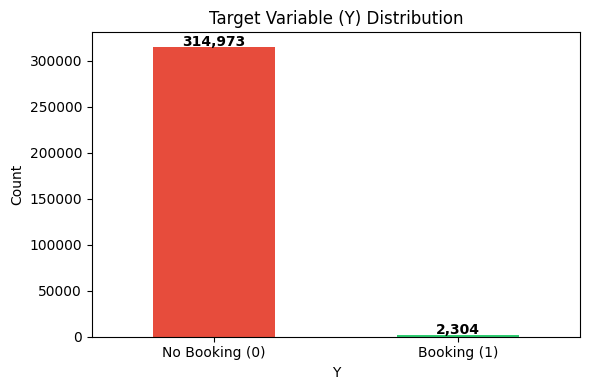

In [10]:
counts = training_data['Y'].value_counts().sort_index()
print(f"Class 0 (no booking): {counts.get(0, 0):,}")
print(f"Class 1 (booking):    {counts.get(1, 0):,}")
print(f"Imbalance ratio Y=1/Y=0: {counts.get(1, 0) / counts.get(0, 1):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['No Booking (0)', 'Booking (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Variable (Y) Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Rozkłady wygenerowanych cech

Sprawdzamy, dla ilu wierszy danych model ma realne informacje z recenzji, a dla ilu widzi tylko brak recenzji (`-1` lub `0`).


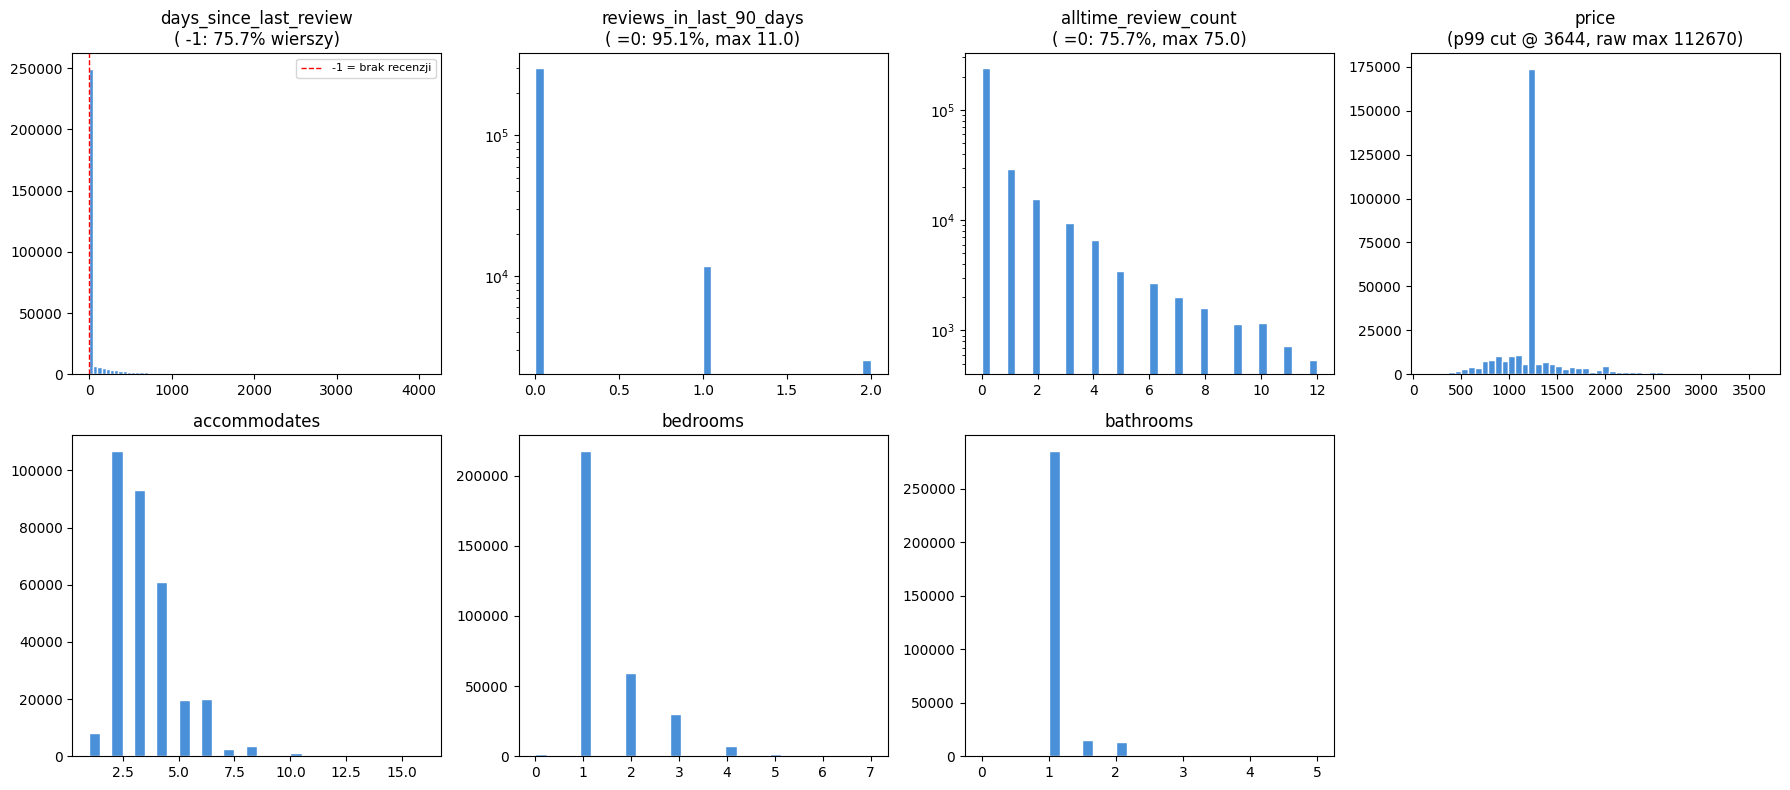

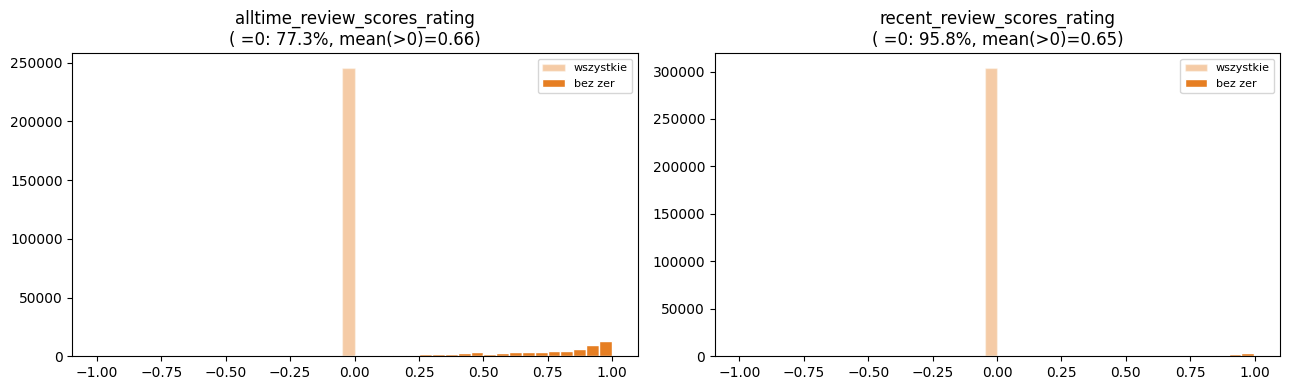

In [11]:
numeric_feats = [
    'days_since_last_review', 'reviews_in_last_90_days', 'alltime_review_count',
    'price', 'accommodates', 'bedrooms', 'bathrooms'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, f in enumerate(numeric_feats):
    ax = axes[i]
    vals = training_data[f].to_numpy()
    # clip outliers
    if f == 'price':
        clip = np.percentile(vals, 99)
        ax.hist(vals[vals <= clip], bins=50, color='#4a90d9', edgecolor='white')
        ax.set_title(f"{f}\n(p99 cut @ {clip:.0f}, raw max {vals.max():.0f})")
    elif f == 'days_since_last_review':
        ax.hist(vals, bins=80, color='#4a90d9', edgecolor='white')
        ax.axvline(-1, color='red', linestyle='--', linewidth=1, label='-1 = brak recenzji')
        ax.set_title(f"{f}\n( -1: {(vals == -1).mean()*100:.1f}% wierszy)")
        ax.legend(fontsize=8)
    elif f in ('reviews_in_last_90_days', 'alltime_review_count'):
        clip = np.percentile(vals, 99)
        ax.hist(vals[vals <= clip], bins=40, color='#4a90d9', edgecolor='white')
        ax.set_yscale('log')
        ax.set_title(f"{f}\n( =0: {(vals == 0).mean()*100:.1f}%, max {vals.max()})")
    else:
        ax.hist(vals, bins=30, color='#4a90d9', edgecolor='white')
        ax.set_title(f)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# rating jako reprezentatywny sentyment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['alltime_review_scores_rating', 'recent_review_scores_rating']):
    v = training_data[col].to_numpy()
    nz = v[v != 0]
    ax.hist(v, bins=40, color='#e67e22', edgecolor='white', alpha=0.4, label='wszystkie')
    ax.hist(nz, bins=40, color='#e67e22', edgecolor='white', label='bez zer')
    ax.set_title(f"{col}\n( =0: {(v == 0).mean()*100:.1f}%, mean(>0)={nz.mean():.2f})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Obserwacje:

- `days_since_last_review = -1` dla ok. 73% wierszy, czyli większość sesji nie ma widocznych recenzji.
- `reviews_in_last_90_days = 0` dla ok. 94% wierszy.
- `price` ma pojedyncze bardzo wysokie wartości. Dla modeli drzewiastych to nie problem.
- Sentymenty są często zerowe, bo wiele ofert nie ma recenzji w danym oknie czasowym.


## Czy cechy różnią się dla Y=0 i Y=1?

Porównujemy podstawowe statystyki dla rezerwacji i braku rezerwacji. Dodatkowo liczymy ROC-AUC dla pojedynczych cech rezerwacji, żeby zobaczyć, czy same w sobie niosą informację (statyczne z listing były sprawdzane już wcześniej).


In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score

key_feats = [
    'days_since_last_review', 'reviews_in_last_90_days', 'alltime_review_count',
    'alltime_review_scores_rating', 'recent_review_scores_rating',
    'alltime_review_scores_location', 'alltime_review_scores_communication'
]

rows = []
for f in key_feats:
    g0 = training_data.loc[training_data['Y'] == 0, f]
    g1 = training_data.loc[training_data['Y'] == 1, f]
    auc = roc_auc_score(training_data['Y'], training_data[f])
    rows.append({
        'feature': f,
        'Y=0 mean': g0.mean(),
        'Y=1 mean': g1.mean(),
        'ratio (1/0)': (g1.mean() / g0.mean()) if g0.mean() not in (0, np.nan) else float('nan'),
        'AUC': auc,
        '|AUC-0.5|': abs(auc - 0.5),
    })
comp = pd.DataFrame(rows).sort_values('|AUC-0.5|', ascending=False)
print("Porównanie Y=0 vs Y=1 i ROC-AUC (sort: |AUC-0.5|)")
print(comp.to_string(index=False, float_format=lambda x: f'{x:8.4f}' if isinstance(x, float) else str(x)))

Porównanie Y=0 vs Y=1 i ROC-AUC (sort: |AUC-0.5|)
                            feature  Y=0 mean  Y=1 mean  ratio (1/0)      AUC  |AUC-0.5|
               alltime_review_count    0.8489    4.0247       4.7412   0.6807     0.1807
       alltime_review_scores_rating    0.1492    0.3623       2.4282   0.6483     0.1483
     alltime_review_scores_location    0.0700    0.1674       2.3924   0.6364     0.1364
             days_since_last_review  156.1471  153.8060       0.9850   0.6350     0.1350
alltime_review_scores_communication    0.0533    0.1288       2.4148   0.6227     0.1227
            reviews_in_last_90_days    0.0625    0.4414       7.0578   0.6042     0.1042
        recent_review_scores_rating    0.0267    0.1543       5.7827   0.5862     0.0862


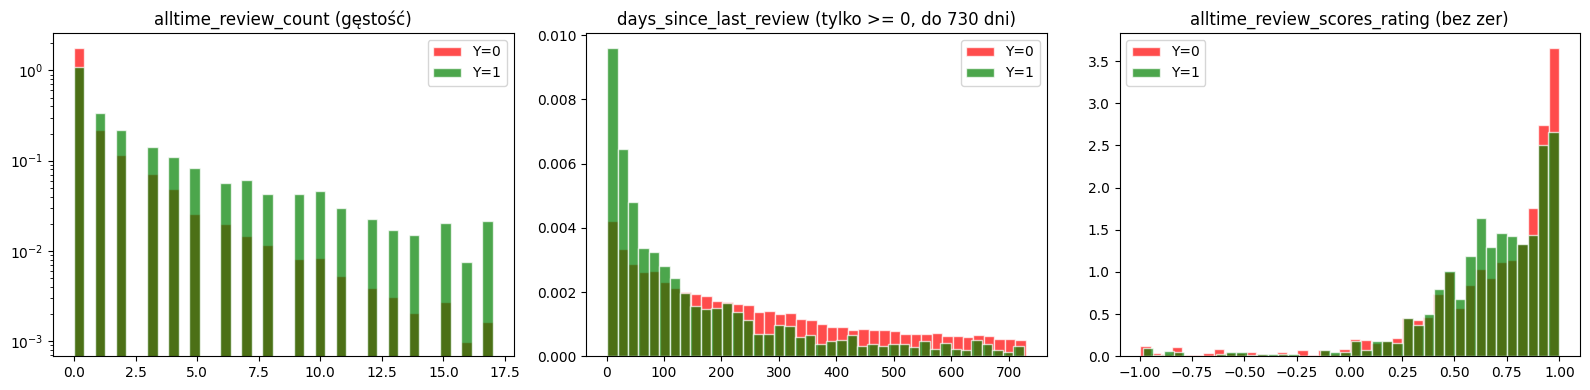

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. alltime_review_count - log-skali, przez długi ogon
ax = axes[0]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'alltime_review_count']
    v_clip = v[v <= np.percentile(training_data['alltime_review_count'], 99.5)]
    ax.hist(v_clip, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_yscale('log')
ax.set_title('alltime_review_count (gęstość)')
ax.legend()

# 2. days_since_last_review
ax = axes[1]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'days_since_last_review']
    v_pos = v[(v >= 0) & (v <= 730)]
    ax.hist(v_pos, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_title('days_since_last_review (tylko >= 0, do 730 dni)')
ax.legend()

# 3. alltime_review_scores_rating
ax = axes[2]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'alltime_review_scores_rating']
    nz = v[v != 0]
    ax.hist(nz, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_title('alltime_review_scores_rating (bez zer)')
ax.legend()

plt.tight_layout()
plt.show()

Wyniki:

- `alltime_review_count` ma najwyższy pojedynczy AUC, ok. 0.68.
- `alltime_review_scores_rating` ma AUC ok. 0.65.
- `days_since_last_review` też różnicuje klasy, choć trzeba pamiętać, że `-1` oznacza brak recenzji.

Wniosek: w cechach recenzji jest sygnał, ale nie jest bardzo silny. Powinno to wystarczyć dla prostego modelu.


## Model bazowy (model A)

Model bazowy to regresja logistyczna na przygotowanych danych treningowych. Dodatkowe przetwarzanie to imputacja (zabezpieczenie inferencji), skalowanie cech numerycznych i one-hot dla kategorii. Całość pakujemy w `Pipeline`, więc artefakt jest samowystarczalny.

Porównujemy go z kilkoma wariantami modelu naiwnego (`DummyClassifier`: stratified, most_frequent, prior, uniform) oraz z regresją logistyczną liczoną tylko na cechach z recenzji — żeby zobaczyć, czy statyczne cechy oferty dokładają sygnał. Używamy ROC-AUC i Average Precision, bo rezerwacji jest bardzo mało względem przypadków bez rezerwacji. Zapisany pipeline (wszystkie cechy) będzie wariantem **A** w teście A/B mikroserwisu.

In [14]:
def make_logreg(num_features, categorical_features):
    """Pipeline regresji logistycznej na wybranym podzbiorze cech."""
    transformers = [('num', Pipeline([('imp', make_imputer()), ('sc', StandardScaler())]), num_features)]
    
    if categorical_features:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features))
    
    pre = ColumnTransformer(transformers)
    
    return Pipeline(
        [
            ('pre', pre),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
        ]
    )

In [15]:
def score(name, baseline_ap, y_te, proba):
    auc = roc_auc_score(y_te, proba) if len(set(proba)) > 1 else 0.5
    ap = average_precision_score(y_te, proba)
    print(f"  {name:42s}  ROC-AUC={auc:.4f}   AP={ap:.4f}  ({ap/baseline_ap:.1f}× baseline)")

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split

feature_cols = num_cols_all + cat_cols
X = training_data[feature_cols]
y = training_data['Y'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Baseline AP: częstość klasy pozytywnej w zbiorze testowym (prosty model, który zawsze przewiduje średnią)
baseline_ap = y_te.mean()
print(f"Baseline AP (= częstość klasy pozytywnej w teście): {baseline_ap:.4f}\n")

# Modele naiwne (DummyClassifier) dla różnych strategii, żeby pokazać, że model ma sens i bije proste heurystyki
print("Modele naiwne (Dummy):")
for strat in ['stratified', 'most_frequent', 'prior', 'uniform']:
    d = DummyClassifier(strategy=strat, random_state=42).fit(X_tr, y_tr)
    try:
        proba = d.predict_proba(X_te)[:, 1]
    except Exception:
        proba = d.predict(X_te).astype(float)
    score(f"Dummy({strat})", baseline_ap, y_te, proba)

# Model A: wszystkie cechy (to jest pipeline, który zapiszemy jako artefakt)
model_a = make_logreg(num_cols_all, cat_cols)
model_a.fit(X_tr, y_tr)
proba_a = model_a.predict_proba(X_te)[:, 1]
print("\nLogisticRegression:")
score("LogReg(balanced) - wszystkie cechy", baseline_ap, y_te, proba_a)

# Wariant tylko na cechach recenzyjnych - sprawdza, czy statyczne cechy listingu dokładają sygnał
review_num = [c for c in num_cols_all if 'review' in c]
model_a_review = make_logreg(review_num, []).fit(X_tr, y_tr)
score("LogReg(balanced) - tylko cechy z recenzji", baseline_ap, y_te, model_a_review.predict_proba(X_te)[:, 1])

Baseline AP (= częstość klasy pozytywnej w teście): 0.0073

Modele naiwne (Dummy):
  Dummy(stratified)                           ROC-AUC=0.4985   AP=0.0073  (1.0× baseline)
  Dummy(most_frequent)                        ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)
  Dummy(prior)                                ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)
  Dummy(uniform)                              ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)

LogisticRegression:
  LogReg(balanced) - wszystkie cechy          ROC-AUC=0.7240   AP=0.0277  (3.8× baseline)
  LogReg(balanced) - tylko cechy z recenzji   ROC-AUC=0.6502   AP=0.0230  (3.2× baseline)


Model A trafia do serwisu jako wariant A.

Dotrenowujemy na wszystkich danych i zapisujemy jako samowystarczalny pipeline (impute + scale + encode + classifier).

In [17]:
import os
import joblib

model_a.fit(X, y)
os.makedirs("../data/processed", exist_ok=True)
joblib.dump(model_a, "../data/processed/model_a_pipeline.joblib")
print("Zapisano pipeline modelu bazowego → data/processed/model_a_pipeline.joblib")

Zapisano pipeline modelu bazowego → data/processed/model_a_pipeline.joblib


Model bazowy A jest wyraźnie lepszy od modelu naiwnego (AP i ROC-AUC powyżej wartości losowej). To jest nasz punkt odniesienia — model docelowy B w `03-modeling.ipynb` powinien być co najmniej tak dobry.

## Próbka inferencyjna

Bierzemy ostatnie 30 dni jako przykładowe dane, dla których model miałby później wygenerować predykcje. Usuwamy `Y`, bo przy prawdziwej predykcji tej informacji jeszcze nie ma.


In [18]:
# Próbka inferencyjna z ostatnich 30 dni danych
latest_date = training_data['timestamp'].max()
cutoff = latest_date - pd.Timedelta(days=30)

inference_sample = training_data[training_data['timestamp'] >= cutoff].copy()
inference_sample = inference_sample.drop(columns=['Y'])  # etykieta niewidoczna przy inferencji

print(f"Próbka inferencyjna: {inference_sample.shape} (ostatnie 30 dni danych)")
inference_sample.head()

Próbka inferencyjna: (508, 31) (ostatnie 30 dni danych)


,user_id,timestamp,listing_id,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,alltime_review_scores_accuracy,...,room_type,accommodates,bedrooms,price,neighbourhood_cleansed,host_is_superhost,host_acceptance_rate,minimum_nights,minimum_maximum_nights,bathrooms
316769,40137464,2025-08-09 20:35:12.006548,955594135974379648,-1.0,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,Unknown,2.0,1.0,1200.0,Vesterbro-Kongens Enghave,Unknown,44.0,1.0,30.0,1.0
316770,360554333,2025-08-09 21:05:24.508420,1244147958257977344,-1.0,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,Entire home/apt,2.0,1.0,1035.0,sterbro,Unknown,0.0,3.0,365.0,1.0
316771,179697571,2025-08-09 21:25:27.516388,1397753249851294464,5.0,0.0,0.6324,0.3592,0.0,0.0,0.32945,...,Private room,1.0,1.0,1200.0,Nrrebro,Yes,100.0,3.0,115.0,1.0
316772,360554333,2025-08-09 21:46:06.508420,1502922937698947584,-1.0,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,Entire home/apt,2.0,1.0,2143.0,Unknown,No,73.0,2.0,365.0,1.0
316773,179697571,2025-08-09 22:20:52.516388,1434115704779021312,-1.0,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,Entire home/apt,3.0,1.0,2050.0,Unknown,Unknown,20.0,5.0,1125.0,2.0


In [19]:
import os
os.makedirs("../data/processed", exist_ok=True)

training_data.to_csv("../data/processed/training_data.csv", index=False)
inference_sample.to_csv("../data/processed/inference_sample.csv", index=False)
print(f"Zapisano training_data.csv ({training_data.shape}) i inference_sample.csv ({inference_sample.shape}) do data/processed/")

Zapisano training_data.csv ((317277, 32)) i inference_sample.csv ((508, 31)) do data/processed/


## Wnioski

- Zbiór treningowy to ok. 317 tys. wierszy; klasa pozytywna (rezerwacja) stanowi ok. 0.73%, więc problem jest mocno niezbalansowany.
- Strategię imputacji braków numerycznych wybraliśmy empirycznie (porównanie AP w walidacji krzyżowej).
- Widać sygnał nie tylko w danych z listings, ale także w liczbie recenzji i średnim sentymencie historycznym; sama cena/liczba osób mają AUC blisko 0.5.
- Model bazowy A (regresja logistyczna) jest wyraźnie lepszy od naiwnego i zapisany jako `model_a_pipeline.joblib`.
- Zapisujemy `training_data.csv` i `inference_sample.csv` dla notatnika modelowania i mikroserwisu.
- Ograniczenia danych: wiele sesji nie ma żadnych widocznych recenzji, a część sentymentów może być zaszumiona przez nieangielskie komentarze.